# Analiza Bazy Danych Centrum Operacyjnego

Ten notatnik służy do interaktywnej analizy danych z bazy PostgreSQL.

In [2]:
import sys
import os
from pathlib import Path

# Dodaj katalog backend do ścieżki, aby móc importować src
backend_dir = str(Path(os.getcwd()).parent)
if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from src.config import settings

# Konfiguracja wyświetlania
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('ggplot')

In [3]:
# Połączenie z bazą danych
# Używamy synchronicznego silnika dla pandasa
db_url = settings.DATABASE_URL.replace('postgresql+asyncpg', 'postgresql')
engine = create_engine(db_url)
print(f"Połączono z bazą: {db_url.split('@')[1]}")

Połączono z bazą: localhost:5432/centrum_operacyjne


## 1. Analiza Artykułów

In [4]:
query = """
SELECT 
    a.id, 
    a.title,
    a.content,
    a.summary,
    s.name as source_name, 
    a.published_at, 
    LENGTH(a.content) as content_length
FROM articles a
JOIN sources s ON a.source_id = s.id
ORDER BY a.scraped_at DESC
"""
df_articles = pd.read_sql(query, engine)
df_articles.head()

,id,title,content,summary,source_name,published_at,content_length
0,398,"Wspaniała niedziela❤️\nWarsztaty, rozmowa, sup...","Wspaniała niedziela❤️\nWarsztaty, rozmowa, sup...",W artykule opisano wspaniałe warsztaty organiz...,Facebook - Gmina Działdowo,2025-12-14 15:15:43,568.0
1,397,💻 Pierwsze laptopy odebrane!\n🚚 Rozpoczęły się...,💻 Pierwsze laptopy odebrane!\n🚚 Rozpoczęły się...,Rozpoczęły się dostawy sprzętu do szkół w rama...,Facebook - Gmina Działdowo,2025-12-16 09:16:21,667.0
2,396,Dziękujemy za zaproszenie🎅🫶 Gratulujemy Wszyst...,Dziękujemy za zaproszenie🎅🫶 Gratulujemy Wszyst...,Artykuł wyraża podziękowania za zaproszenie na...,Facebook - Gmina Działdowo,2025-12-18 18:00:05,114.0
3,395,📢 Nowa jakość usług społecznych w Gminie Dział...,📢 Nowa jakość usług społecznych w Gminie Dział...,Gminny Ośrodek Pomocy Społecznej w Gminie Dzia...,Facebook - Gmina Działdowo,2025-12-22 12:20:48,720.0
4,394,Zakończyliśmy realizację zadania nr 9\n\nZajęc...,Zakończyliśmy realizację zadania nr 9\n\nZajęc...,Zakończono realizację zadania nr 9 pod tytułem...,Facebook - Gmina Działdowo,2025-12-22 12:23:09,706.0


In [6]:
df_articles.shape

(140, 7)

In [5]:
df_articles.source_name.value_counts() 


source_name
Moje Działdowo                41
Gmina Rybno                   34
Klikaj.info                   34
Facebook - Syla               20
Facebook - Gmina Działdowo    11
Name: count, dtype: int64

### 2. Sprawdzenie z jakich źródeł pochodz artykuły do generowania summaryc z dnia 2026-01-11

In [6]:
df_articles['published_at'] = pd.to_datetime(df_articles['published_at']).dt.date

In [7]:
data_find = pd.Timestamp("2026-01-11").date()

In [9]:
articles_latest = df_articles[df_articles["published_at"] == data_find]

In [16]:
articles_latest[articles_latest['source_name'] == "Moje Działdowo"].content.values[1]

'Ślubowanie klas OPW i humanistycznej to nie tylko tradycja, ale także moment integrujący społeczność szkolną i budujący poczucie przynależności. Uczniom życzymy sukcesów, wytrwałości i wielu inspirujących doświadczeń w nadchodzących latach nauki.\nMO'

In [27]:
df_articles.loc[
    (df_articles['source_name'] == "Facebook - Syla") & (df_articles['summary'].notna())
]

,id,title,content,summary,source_name,published_at,content_length
11,387,✅ Rumian i SiS Rybno zagrają po dwa mecze w pr...,✅ Rumian i SiS Rybno zagrają po dwa mecze w pr...,W najbliższą niedzielę odbędą się mecze halowe...,Facebook - Syla,2026-01-09 15:01:04,1589.0
12,386,❤️ WOŚP w Rybnie – gramy razem mimo wszystko! ...,❤️ WOŚP w Rybnie – gramy razem mimo wszystko! ...,Finał Wielkiej Orkiestry Świątecznej Pomocy w ...,Facebook - Syla,2026-01-09 16:35:12,1205.0
13,385,Polecamy nową stronę przyrodniczą z terenu Gmi...,Polecamy nową stronę przyrodniczą z terenu Gmi...,Zarekomendowano nową stronę przyrodniczą 'Okie...,Facebook - Syla,2026-01-09 20:10:14,258.0
14,384,Hallo Rybno! Czy ktoś może znalazł tablice rej...,Hallo Rybno! Czy ktoś może znalazł tablice rej...,W artykule poszukiwane są tablice rejestracyjn...,Facebook - Syla,2026-01-09 21:43:58,111.0
15,383,Dzień dobry wszystkim! 🎄Mamy 10 stycznia 💙 Życ...,Dzień dobry wszystkim! 🎄Mamy 10 stycznia 💙 Życ...,W przesłanym ogłoszeniu apeluje się do mieszka...,Facebook - Syla,2026-01-10 06:11:03,384.0
16,382,Aktualne oferty pracy w Powiatowym Urzędzie Pr...,Aktualne oferty pracy w Powiatowym Urzędzie Pr...,Powiatowy Urząd Pracy w Działdowie prezentuje ...,Facebook - Syla,2026-01-10 09:01:39,110.0
17,381,❤️ WOŚP w Rybnie – gramy razem mimo wszystko! ...,❤️ WOŚP w Rybnie – gramy razem mimo wszystko! ...,W Rybnie organizowana jest akcja na rzecz Wiel...,Facebook - Syla,2026-01-10 10:35:06,1242.0
18,380,❤️ WOŚP w Rybnie – gramy razem mimo wszystko! ...,❤️ WOŚP w Rybnie – gramy razem mimo wszystko! ...,W Rybnie odbywa się akcja związana z Wielką Or...,Facebook - Syla,2026-01-10 10:49:15,1430.0
19,379,"‼️ PRACA Sala w Siwym ""Siwy Dym"" ‼️\nStanowisk...","‼️ PRACA Sala w Siwym ""Siwy Dym"" ‼️\nStanowisk...",W miejscowości Hartowiec poszukiwany jest prac...,Facebook - Syla,2026-01-10 13:45:20,751.0
20,378,Z wielką przyjemnością uczestniczyliśmy dziś w...,Z wielką przyjemnością uczestniczyliśmy dziś w...,W Działdowie odbyło się wyjątkowe wydarzenie p...,Facebook - Syla,2026-01-10 21:39:20,845.0


In [28]:
df_articles.loc[
    (df_articles['source_name'] == "Facebook - Syla")].loc[21, ['summary', 'content']].values

array(['Rozpoczęło się głosowanie w konkursie fotograficznym "Zima w obiektywie mieszkańców Gminy Rybno". Organizator, Serwis Informacyjny Syla, ogłosił listę finalistów oraz terminy głosowania, które trwa od 10 do 11 stycznia 2026 roku.',
       "GŁOSOWANIE CZAS START ❄️📸 KONKURS FOTOGRAFICZNY 📸❄️\n„Zima w obiektywie mieszkańców Gminy Rybno”\n\nDziękujemy za ogromny odzew i wszystkie nadesłane zdjęcia! ❄️📷\n\nPo obradach jury przedstawiamy autorów 10 fotografii, które awansowały do drugiego etapu konkursu. Finaliści to: Anna Marek, Anna Rucińska, Beata Kowalewska, Kasia Mulka, Krzysztof Wasielewski, Marcin Zieliński, Mateusz Truszczyński, Natalia Rozentalska, Sylwia Birlet i Violetta Grabowska. Zdjęcia są wstawione losowo 🥶 Musimy powtórzyć głosowanie, ponieważ okazało się, że dwa zdjęcia, które ukazały się w poprzednim poście, były autorstwa kogoś zupełnie innego. \n\n👉 Teraz decydujecie Wy!\n\nZdjęcie, które otrzyma najwięcej reakcji „Lubię to” 👍 pod fotografią, ma szansę zdobyć nag

## 3. Statystyki Pogodowe

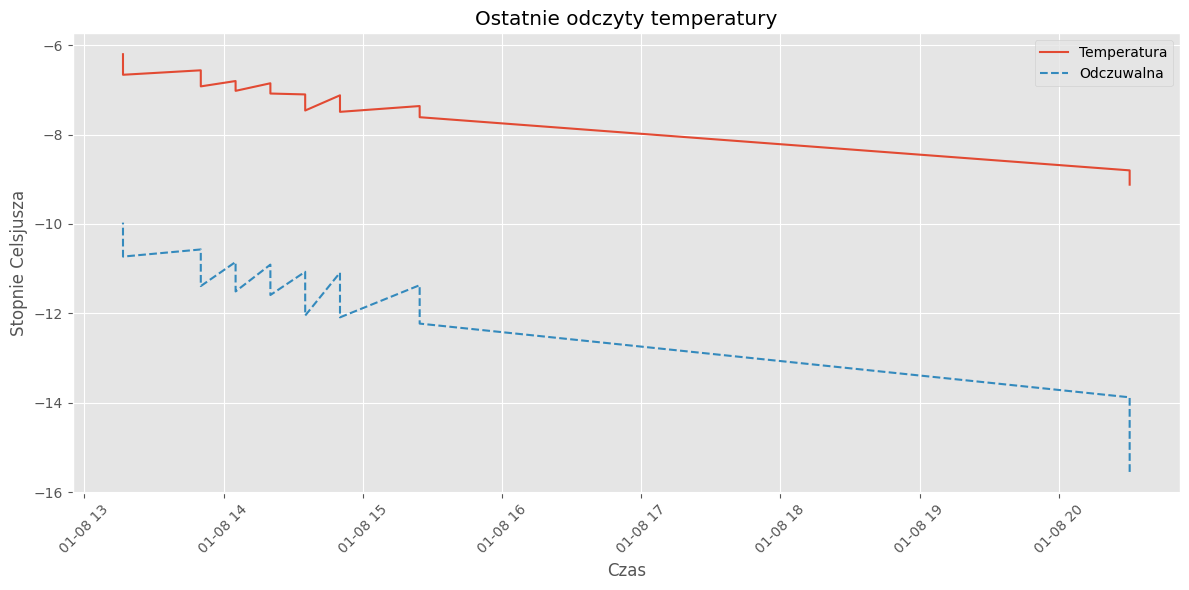

In [10]:
query_weather = """
SELECT temperature, feels_like, fetched_at, location 
FROM weather 
ORDER BY fetched_at DESC 
LIMIT 100
"""
df_weather = pd.read_sql(query_weather, engine)

plt.figure(figsize=(12, 6))
plt.plot(df_weather['fetched_at'], df_weather['temperature'], label='Temperatura')
plt.plot(df_weather['fetched_at'], df_weather['feels_like'], label='Odczuwalna', linestyle='--')
plt.title('Ostatnie odczyty temperatury')
plt.xlabel('Czas')
plt.ylabel('Stopnie Celsjusza')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()